In [1]:
import numpy as np 
import pandas as pd 
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split,cross_val_score

In [2]:
df=pd.read_csv('train.csv')

In [ ]:
prof=ProfileReport(df)
prof.to_file(output_file='report.html')

In [4]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
df.duplicated().sum()

0

In [7]:
df.sample(10)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
194894,194894,42,1,3,150,248,0,2,163,0,0.1,1,0,3,Absence
493193,493193,49,1,3,152,211,0,2,173,0,1.0,1,0,3,Absence
393942,393942,58,1,3,160,239,0,0,178,1,0.0,1,0,3,Absence
17043,17043,52,0,4,130,236,0,0,143,0,0.0,1,0,3,Absence
523476,523476,52,1,2,130,233,0,0,154,0,0.0,1,0,3,Absence
427780,427780,64,1,4,178,254,0,2,157,0,0.0,2,0,7,Presence
205081,205081,63,1,2,165,201,0,0,182,0,1.0,1,0,3,Absence
75658,75658,58,0,3,150,211,0,0,182,0,0.0,1,0,3,Absence
590222,590222,62,0,1,130,254,0,0,162,0,2.0,1,0,3,Absence
153688,153688,46,1,2,154,266,0,0,159,0,0.0,1,1,3,Absence


In [8]:
df.drop('id',axis=1,inplace =True)

In [9]:
df.sample(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
380364,44,1,3,138,188,0,0,154,0,0.1,1,0,3,Absence
392085,67,1,4,125,196,0,2,157,1,1.6,2,0,7,Presence
86779,41,1,4,120,268,0,2,157,0,0.0,2,0,7,Presence
237601,48,1,3,125,244,0,2,162,1,1.0,1,2,7,Absence
383876,59,1,4,105,288,0,2,144,1,0.4,1,1,7,Presence


In [10]:
df.shape

(630000, 14)

In [11]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [12]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [13]:
import seaborn as sns 
import matplotlib.pyplot as plt

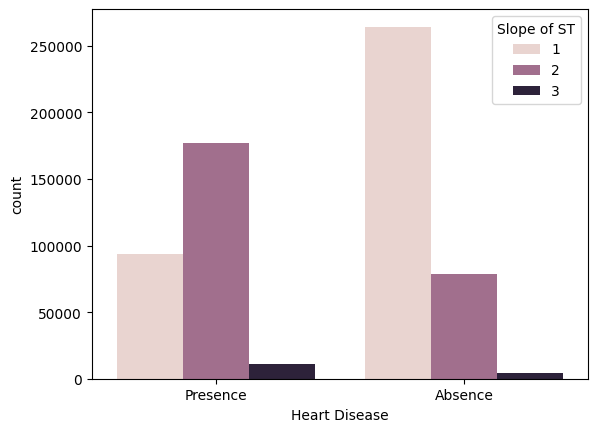

In [14]:
# %matplotlib inline
sns.countplot (x=df['Heart Disease'],hue=df['Slope of ST'])
plt.show()

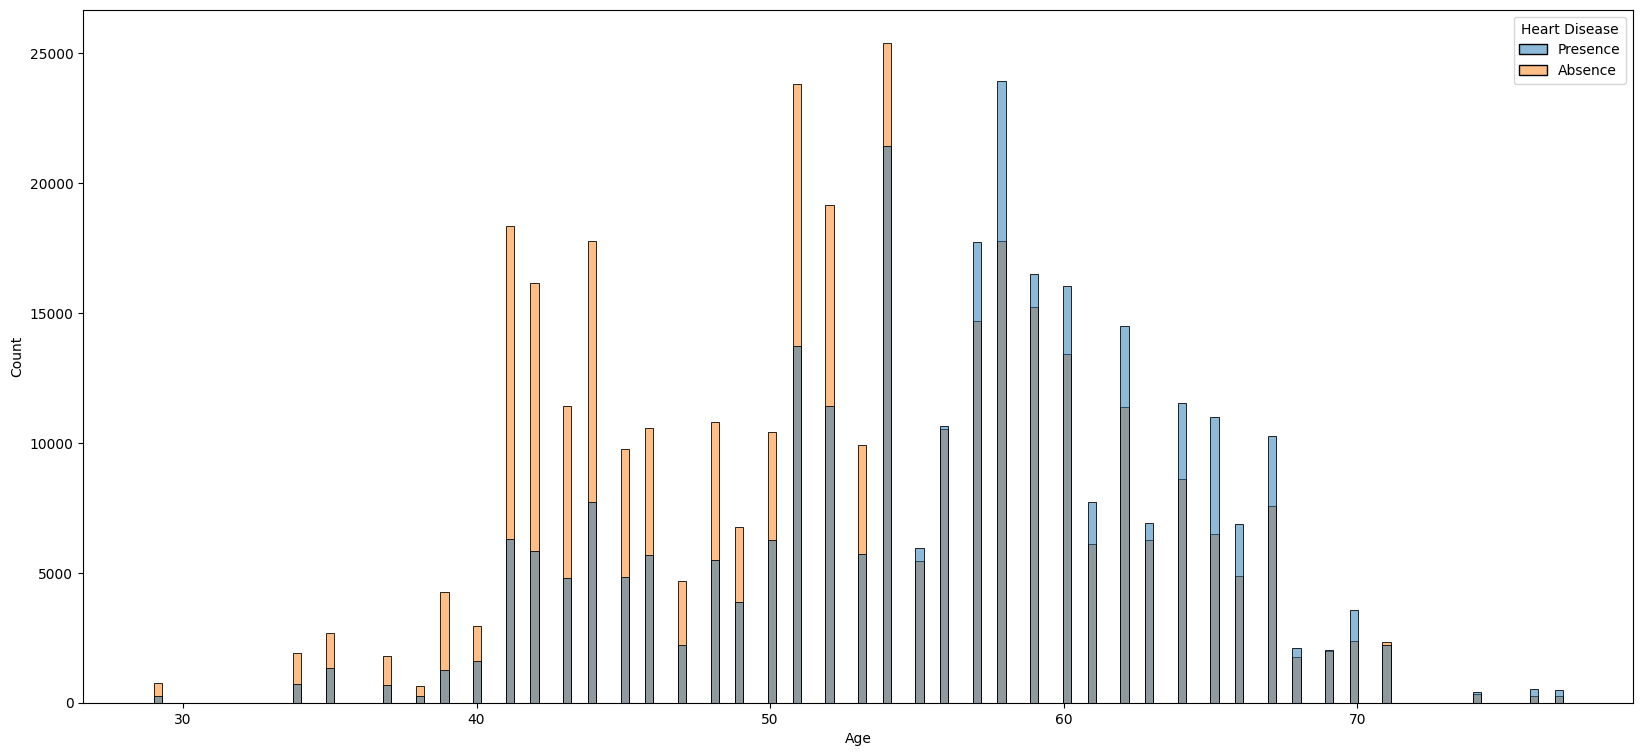

In [15]:
plt.figure(figsize=(20,9))
sns.histplot(x='Age',data=df,hue='Heart Disease')
plt.show()

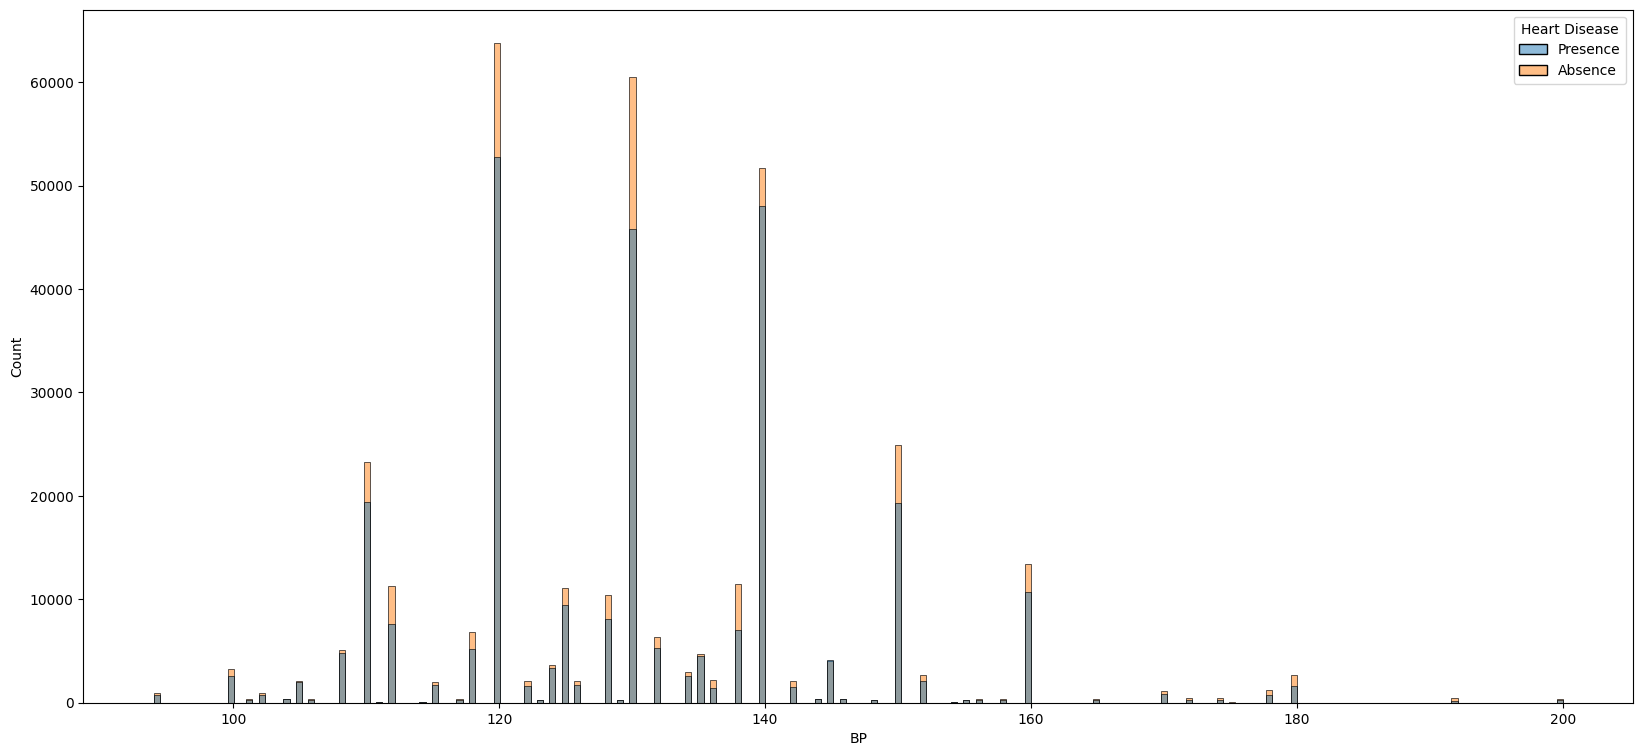

In [16]:
plt.figure(figsize=(20,9))
sns.histplot(x='BP',data=df,hue='Heart Disease')
plt.show()

In [18]:
import matplotlib
matplotlib.get_backend()

'module://matplotlib_inline.backend_inline'

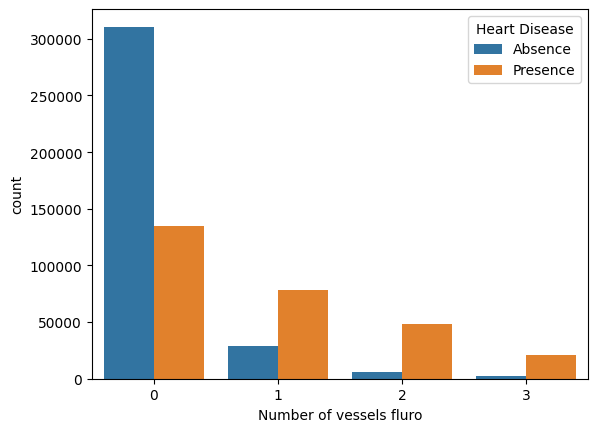

In [19]:
sns.countplot(x='Number of vessels fluro',data=df,hue='Heart Disease')
plt.show()

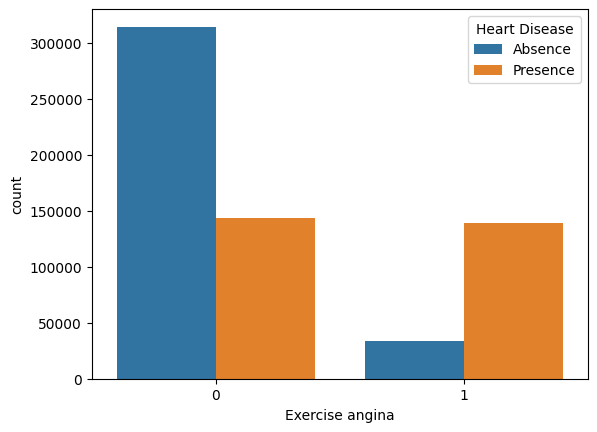

In [20]:
sns.countplot(x='Exercise angina',data=df,hue='Heart Disease')
plt.show()

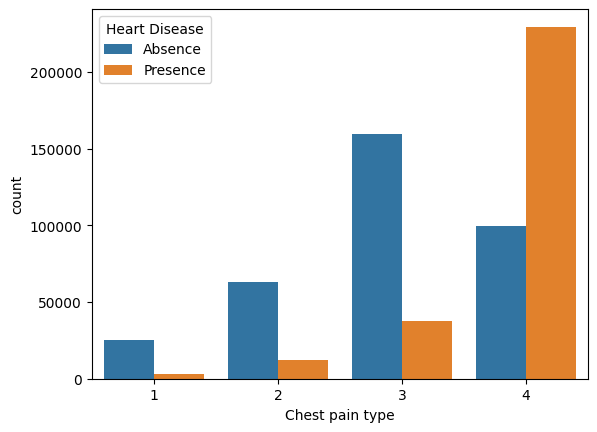

In [21]:
sns.countplot(x='Chest pain type',data=df,hue='Heart Disease')
plt.show()

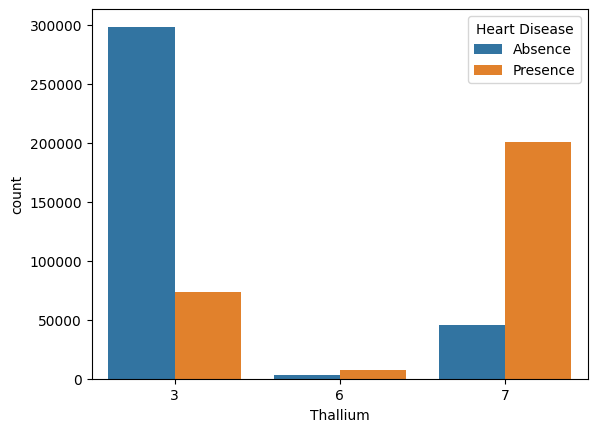

In [22]:
sns.countplot(x='Thallium',data=df,hue='Heart Disease')
plt.show()

In [23]:
df['Thallium'].unique()

array([7, 3, 6], dtype=int64)

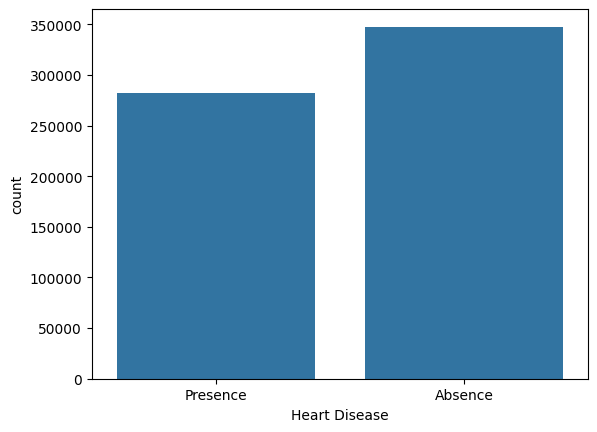

In [24]:
sns.countplot(x='Heart Disease',data =df)
plt.show()

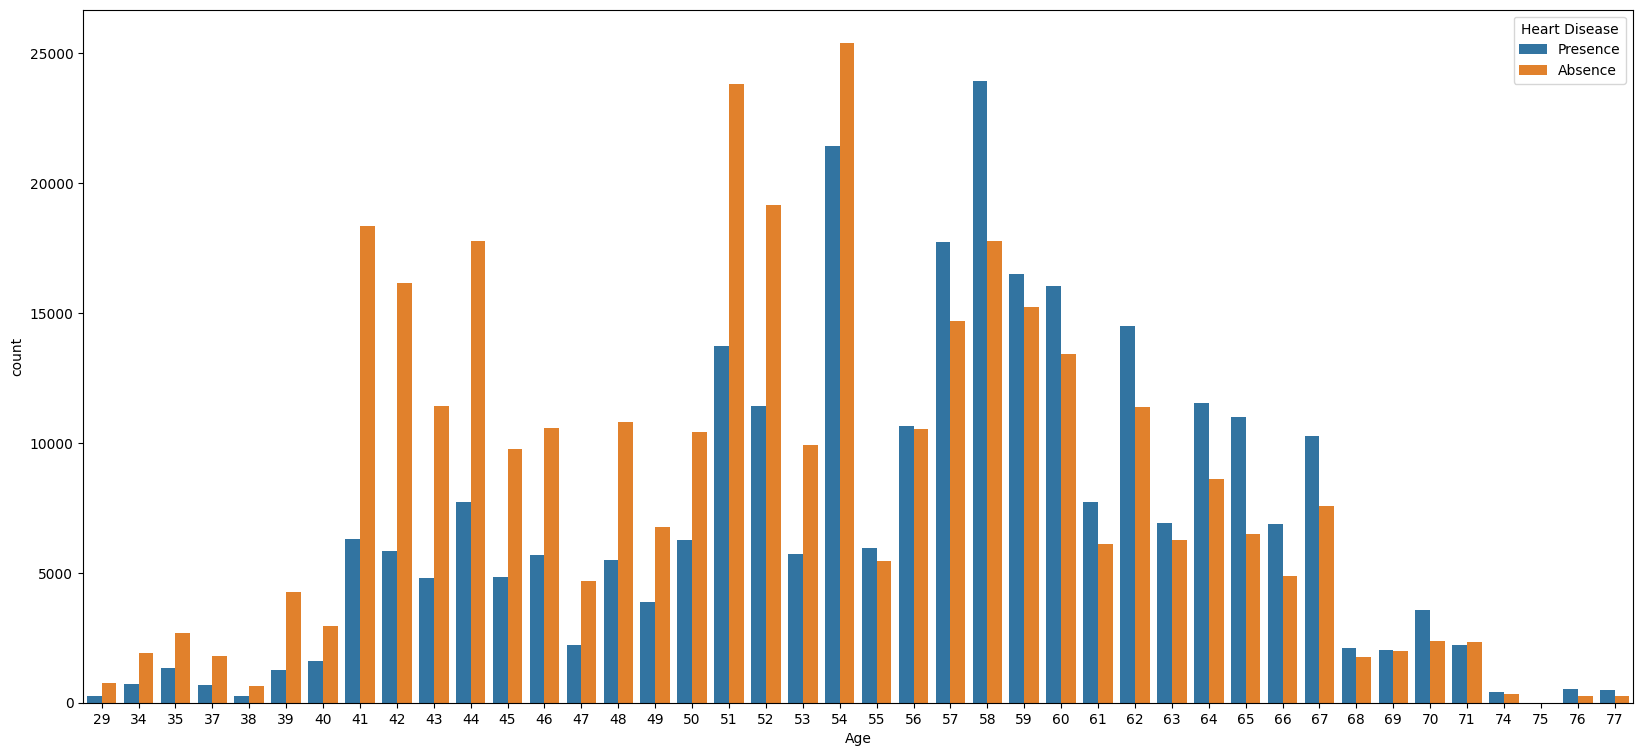

In [25]:
plt.figure(figsize=(20,9))
sns.countplot(x='Age',hue='Heart Disease',data=df)
plt.show()

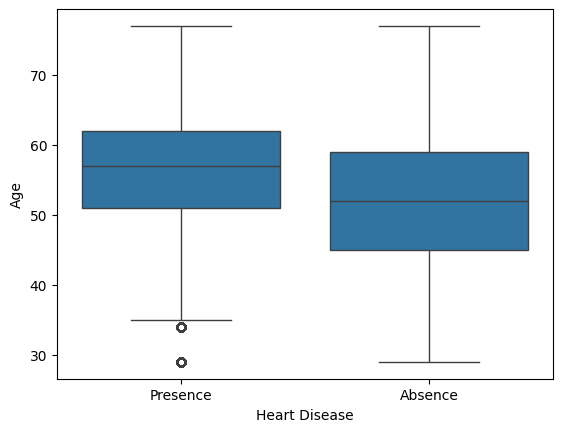

In [26]:
sns.boxplot(x='Heart Disease',y='Age',data=df)
plt.show()

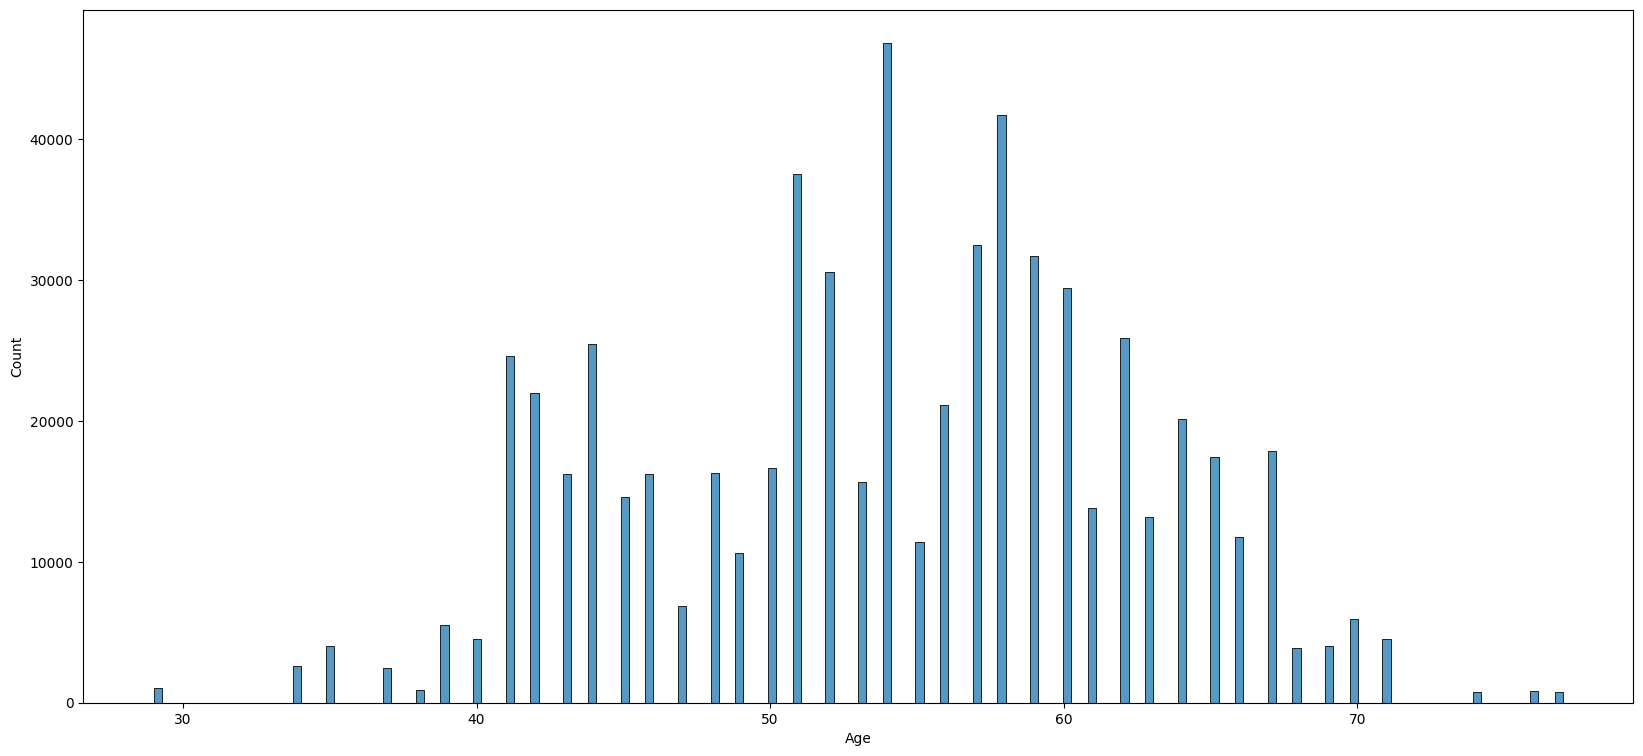

In [27]:
plt.figure(figsize=(20,9))
sns.histplot(df['Age'],kde=False)
plt.show()

columns for ohe  
chest pain type  
ekg results  
slope fo st  
thallium

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [29]:
df['Heart Disease'] = df['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

In [30]:
X=df.drop('Heart Disease',axis=1)
y=df['Heart Disease']

In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [32]:
ohe_cols=['Chest pain type','EKG results','Slope of ST','Thallium']

## Preprocessing 

In [33]:
preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),ohe_cols)
    ],
    remainder='passthrough'
)

In [34]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [35]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score, roc_auc_score, roc_curve,classification_report,confusion_matrix


In [38]:
rfc=RandomForestClassifier(
    n_jobs=-1,
    max_samples=0.3,
    max_depth=15,
    n_estimators=500,
    random_state=42,
    max_features=0.7
)

In [39]:
rfc.fit(X_train,y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
rfc_pred=rfc.predict(X_test)

In [41]:
accuracy_score(rfc_pred,y_test)*100

88.46507936507936

In [42]:
f1_score(y_test,rfc_pred)

0.8702228730623616

In [43]:
classification_report(y_test,rfc_pred)

'              precision    recall  f1-score   support\n\n           0       0.89      0.90      0.90     69564\n           1       0.88      0.86      0.87     56436\n\n    accuracy                           0.88    126000\n   macro avg       0.88      0.88      0.88    126000\nweighted avg       0.88      0.88      0.88    126000\n'

<Axes: >

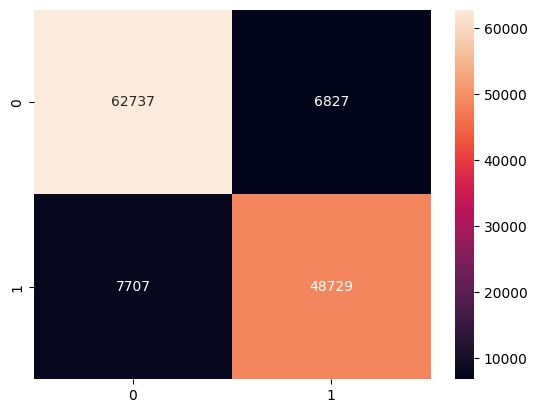

In [44]:
cm=confusion_matrix(y_test,rfc_pred)
sns.heatmap(cm,annot=True,fmt='d')

In [45]:
cross_score_rfc=cross_val_score(rfc,X,y,cv=5)

In [46]:
cross_score_rfc

array([0.88634127, 0.88518254, 0.88586508, 0.88497619, 0.88512698])

In [47]:
print(f'mean : ',cross_score_rfc.mean())
print(f'std : ',cross_score_rfc.std())

mean :  0.8854984126984127
std :  0.0005206349206349252


In [48]:
df['Heart Disease'].value_counts(normalize=True)

Heart Disease
0    0.55166
1    0.44834
Name: proportion, dtype: float64

In [49]:
rfc_feat=pd.Series(
    rfc.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False)

In [50]:
rfc_feat

cat__Thallium_3                       0.328820
cat__Chest pain type_4                0.139061
cat__Thallium_7                       0.105408
remainder__Max HR                     0.092697
remainder__Number of vessels fluro    0.074338
remainder__Age                        0.041661
remainder__ST depression              0.041116
remainder__Cholesterol                0.041024
cat__Slope of ST_1                    0.035490
remainder__Exercise angina            0.029983
remainder__BP                         0.028190
remainder__Sex                        0.017194
cat__Slope of ST_2                    0.004919
cat__EKG results_2                    0.004756
cat__EKG results_0                    0.004567
remainder__FBS over 120               0.003321
cat__Chest pain type_3                0.002184
cat__Chest pain type_2                0.001561
cat__Thallium_6                       0.001289
cat__Chest pain type_1                0.001273
cat__Slope of ST_3                    0.000900
cat__EKG resu

# XGboost

In [51]:
from xgboost import XGBClassifier

In [52]:
xgb=XGBClassifier(
    tree_method='hist',
    n_estimators=1200,
    n_jobs=-1,
    subsample=0.8,
    learning_rate=0.05,
    colsample_bytree=0.8,
    max_depth=5 ,
    random_state=42
    
)

In [53]:
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [54]:
xgb_pred=xgb.predict(X_test)

In [55]:
accuracy_score(xgb_pred,y_test)*100

88.75238095238095

In [56]:
xgbscore=cross_val_score(xgb,X_train,y_train,cv=5)

In [57]:
print(f"Mean : ",xgbscore.mean())
print(f"std : ",xgbscore.std())

Mean :  0.8886428571428571
std :  0.0005813322766915551


In [58]:
f1_score(y_test,xgb_pred)

0.8735004284490145

In [59]:
xgb_feat=pd.Series(
    xgb.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False)

In [60]:
xgb_feat

cat__Thallium_3                       0.457233
cat__Chest pain type_4                0.211995
cat__Thallium_7                       0.105473
remainder__Exercise angina            0.055529
cat__Slope of ST_1                    0.053953
remainder__Number of vessels fluro    0.039484
remainder__Sex                        0.027331
remainder__Max HR                     0.010606
remainder__ST depression              0.009766
cat__EKG results_2                    0.009654
cat__Chest pain type_3                0.003600
remainder__Age                        0.003118
cat__Chest pain type_1                0.002819
cat__Slope of ST_2                    0.002344
cat__EKG results_0                    0.001580
remainder__Cholesterol                0.001129
cat__Chest pain type_2                0.000844
remainder__BP                         0.000818
cat__Thallium_6                       0.000730
remainder__FBS over 120               0.000723
cat__Slope of ST_3                    0.000714
cat__EKG resu

# Saving the model 

In [74]:
import joblib

joblib.dump(xgb, "heart_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']